# [ベースライン] 第2回データ分析コンペティション：NFL Draft Prediction

　本ノートブックでは、「スポーツパフォーマンステストおよび選手情報をもとに、NFLドラフト指名の有無（Drafted）を予測する」タスクのベースラインモデルを構築します。

　ベースラインモデルとは、与えられた機械学習タスクに対して、まず最初に構築されるシンプルなモデルであり、今後のモデル開発・性能向上の出発点となるものです。

　本ノートブックを上から順番に実行していけば、正常に提出できる予測ファイルが作成されます。

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [373]:
# モジュールのインポート
import numpy as np  # 数値計算や配列操作を行うためのライブラリ
import pandas as pd  # 表形式のデータを扱うためのライブラリ
import matplotlib.pyplot as plt  # データ可視化のための基本的なグラフ描画ライブラリ
import seaborn as sns  # 高機能な統計グラフを描画するライブラリ
from sklearn.preprocessing import LabelEncoder  # カテゴリ変数を数値に変換するエンコーダ
from sklearn.ensemble import RandomForestClassifier  # ランダムフォレストによる分類器
from sklearn.model_selection import StratifiedKFold  # 層化K分割交差検証を行うクラス
from sklearn.metrics import roc_auc_score  # ROC AUCスコアを計算する評価指標

## 2. データ読み込み

In [374]:
train = pd.read_csv('data/train.csv')  # 学習用データの読み込み
test = pd.read_csv('data/test.csv')    # テスト用データの読み込み

In [375]:
print('Train:', train.shape)
print('Test:', test.shape)

Train: (2781, 16)
Test: (696, 15)


In [376]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [377]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

## 3. データの分析・EDA

In [378]:
train.isnull().sum()

Id                    0
Year                  0
Age                 435
School                0
Height                0
Weight                0
Sprint_40yd         145
Vertical_Jump       554
Bench_Press_Reps    721
Broad_Jump          581
Agility_3cone       970
Shuttle             912
Player_Type           0
Position_Type         0
Position              0
Drafted               0
dtype: int64

In [379]:
test.isnull().sum()

Id                    0
Year                  0
Age                 115
School                0
Height                0
Weight                0
Sprint_40yd          29
Vertical_Jump       143
Bench_Press_Reps    184
Broad_Jump          147
Agility_3cone       247
Shuttle             228
Player_Type           0
Position_Type         0
Position              0
dtype: int64

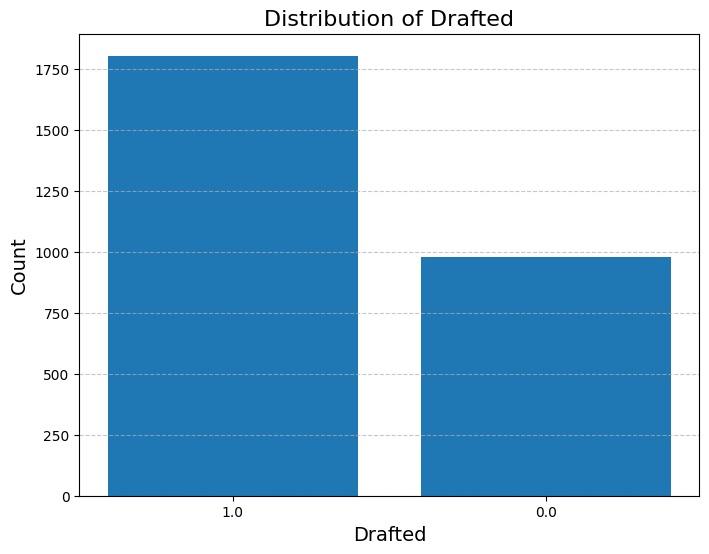

In [380]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [381]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


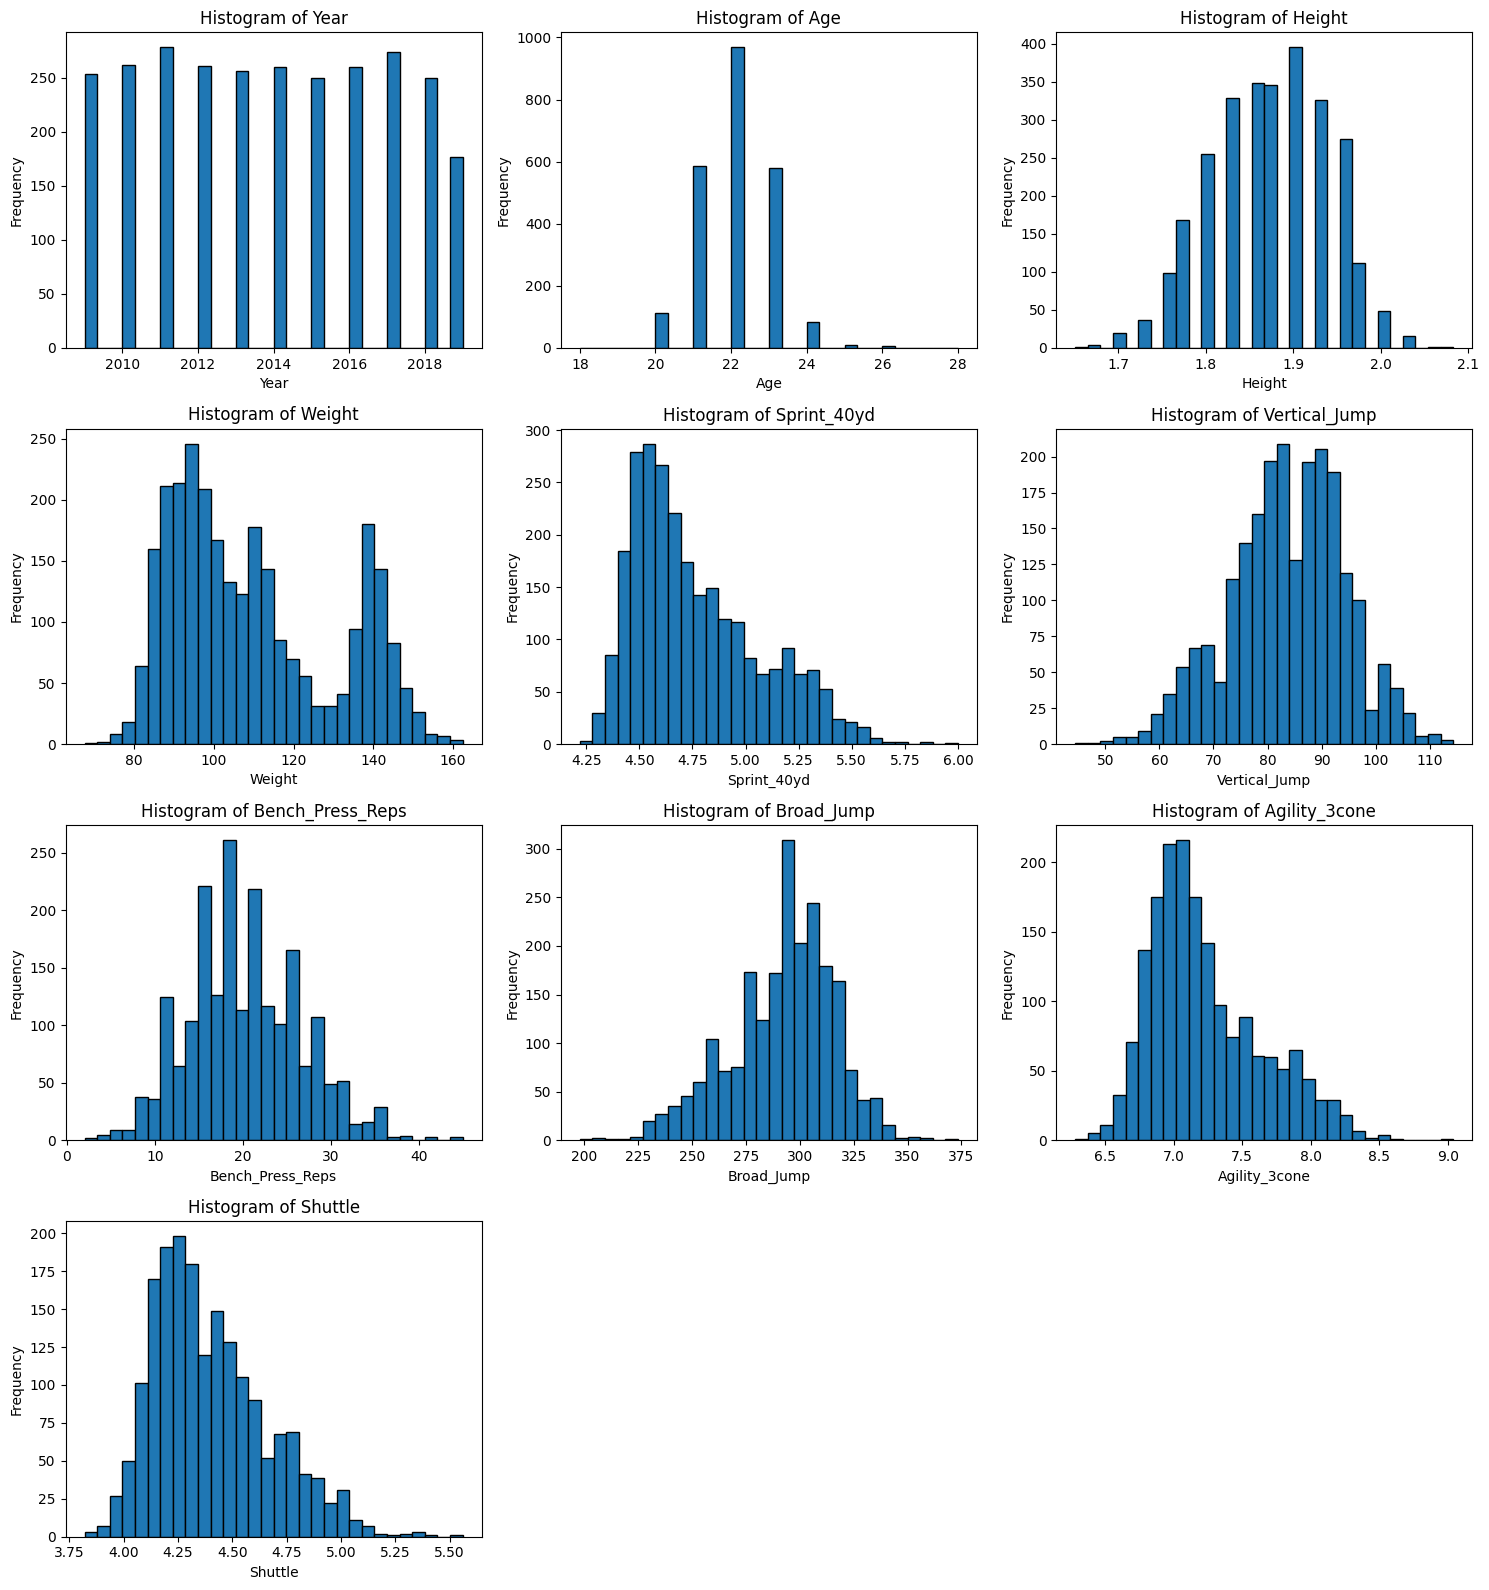

In [382]:
# 数値列だけを取り出す（Id, Drafted列は除く）
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# プロット
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

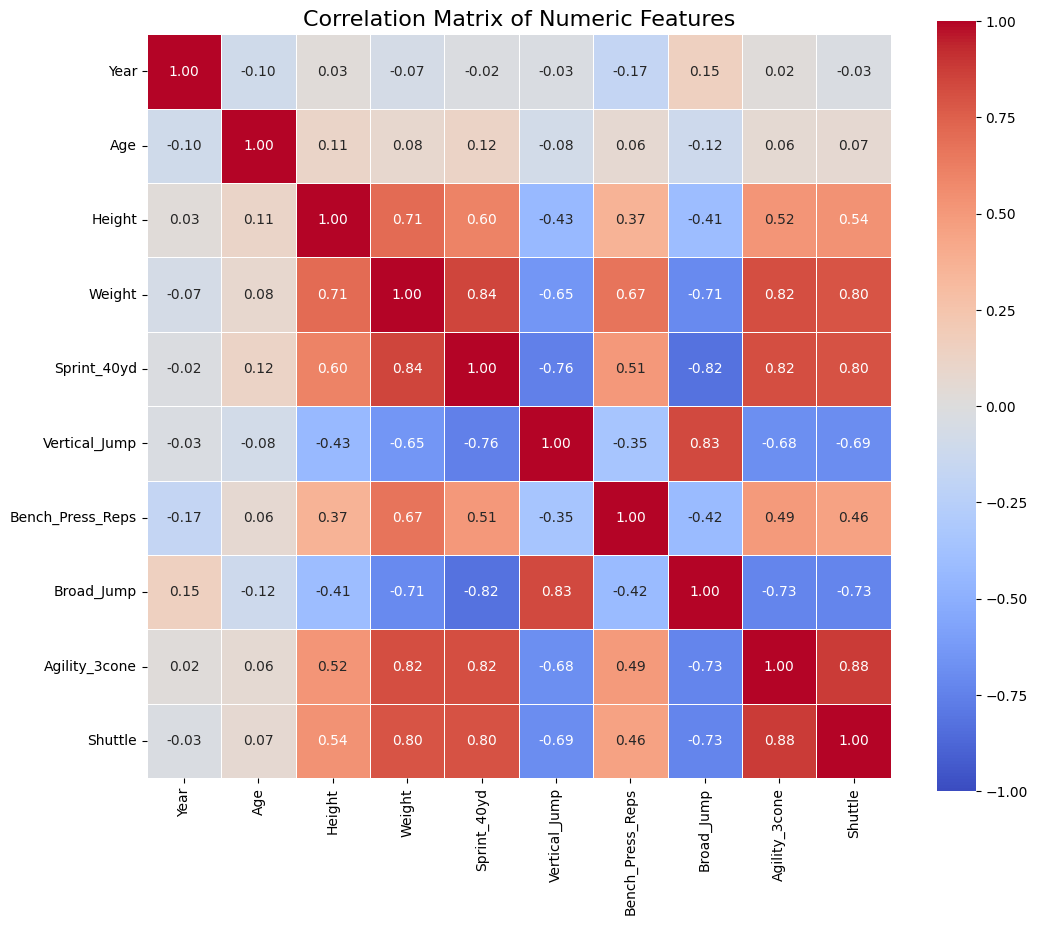

In [383]:
# 数値列だけを取り出す（Id, Drafted列は除く）
numeric_cols = train.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# 相関行列を計算
corr_matrix = numeric_cols.corr()

# ヒートマップをプロット
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

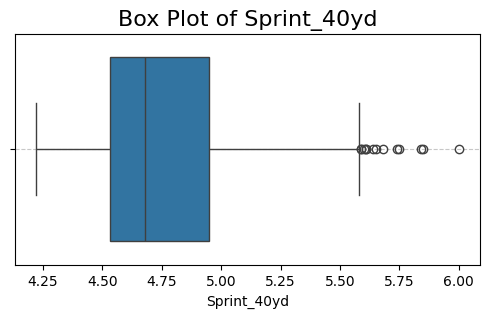

In [384]:
# 箱ひげ図を描画
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

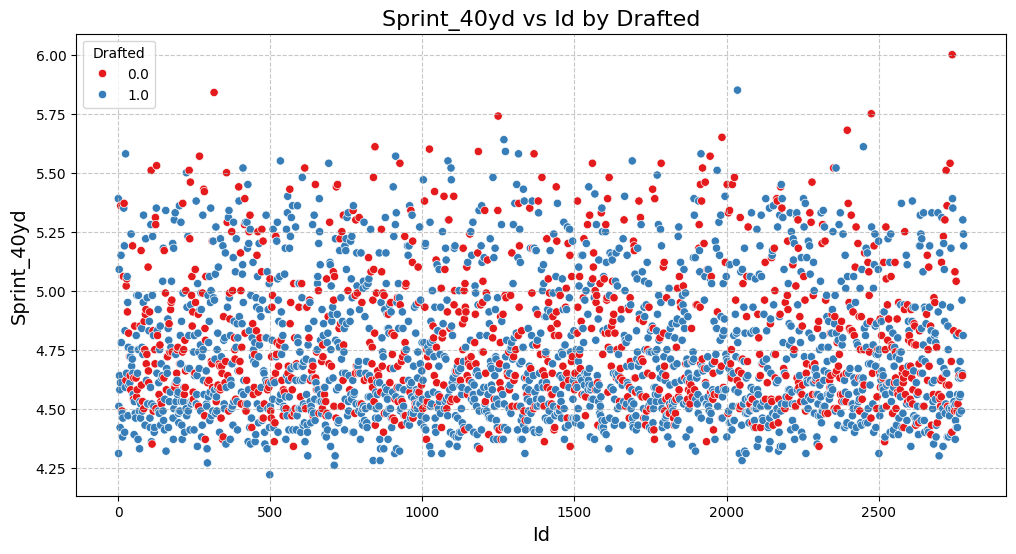

In [385]:
# 横軸にId、縦軸にSprint_40ydをプロット
# Dratedごとに色分け
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='Id', y='Sprint_40yd', hue='Drafted', palette='Set1')
plt.title('Sprint_40yd vs Id by Drafted', fontsize=16)
plt.xlabel('Id', fontsize=14)
plt.ylabel('Sprint_40yd', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

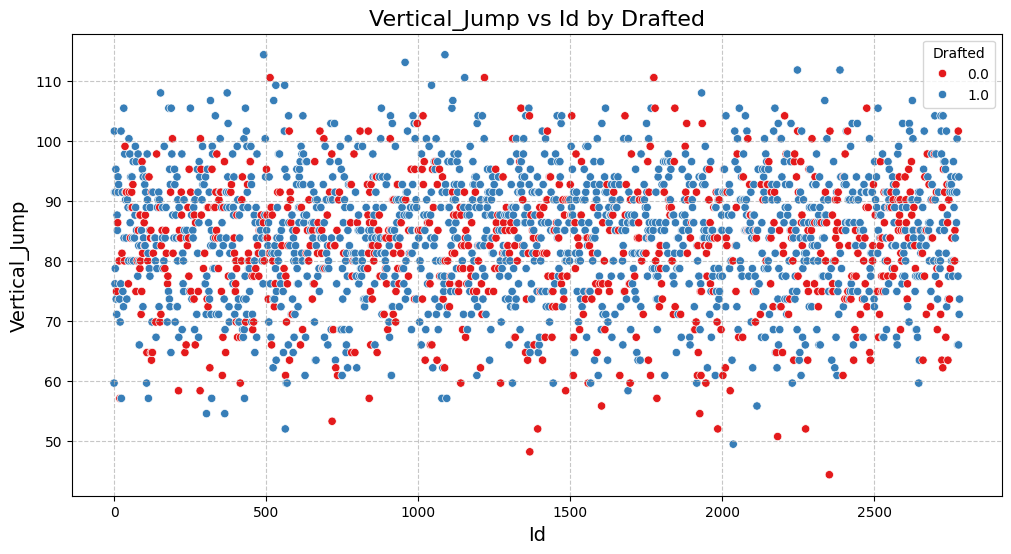

In [386]:
# 横軸にId、縦軸にVertical_Jumpをプロット
# Dratedごとに色分け
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='Id', y='Vertical_Jump', hue='Drafted', palette='Set1')
plt.title('Vertical_Jump vs Id by Drafted', fontsize=16)
plt.xlabel('Id', fontsize=14)
plt.ylabel('Vertical_Jump', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

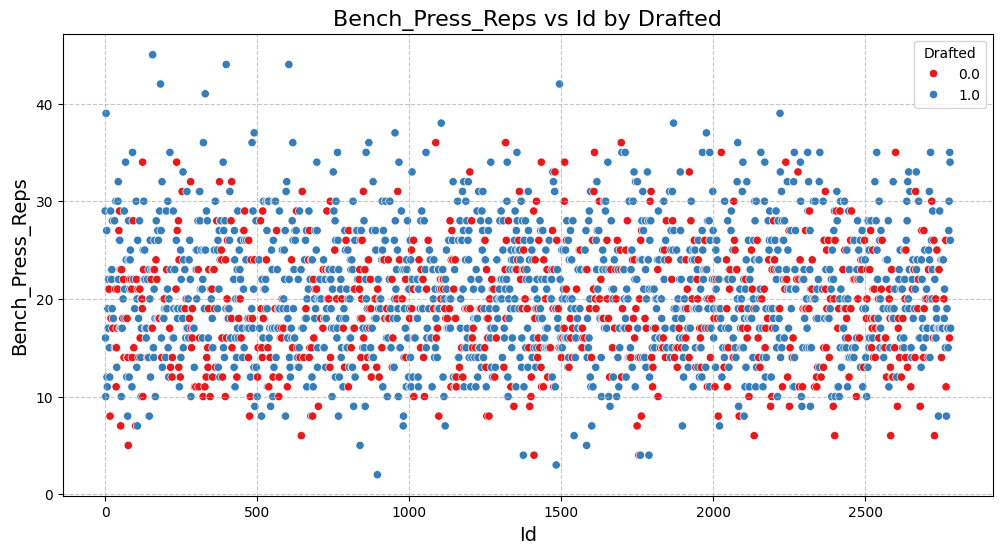

In [387]:
# 横軸にId、縦軸にBench_Press_Repsをプロット
# Dratedごとに色分け
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='Id', y='Bench_Press_Reps', hue='Drafted', palette='Set1')
plt.title('Bench_Press_Reps vs Id by Drafted', fontsize=16)
plt.xlabel('Id', fontsize=14)
plt.ylabel('Bench_Press_Reps', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

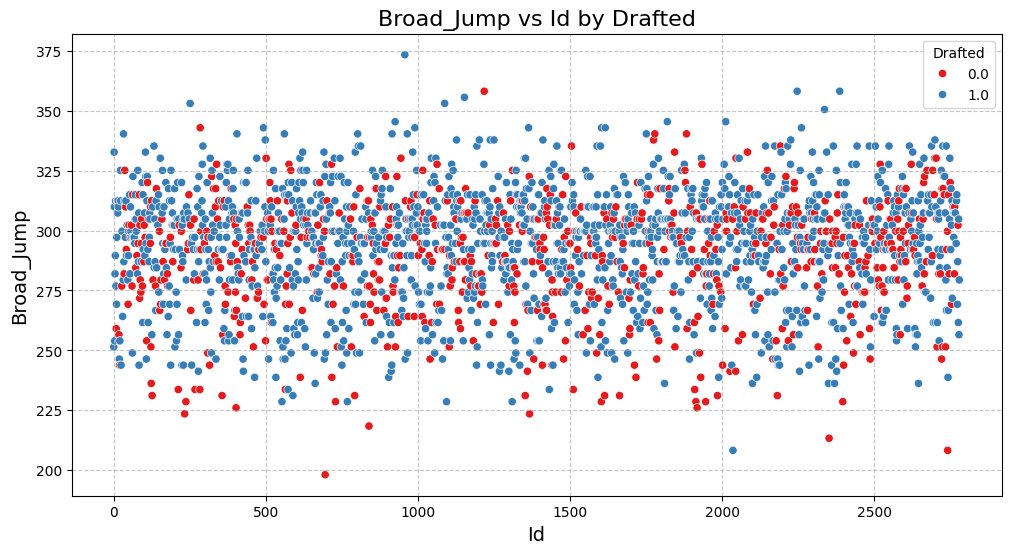

In [388]:
# 横軸にId、縦軸にBroad_Jumpをプロット
# Dratedごとに色分け
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='Id', y='Broad_Jump', hue='Drafted', palette='Set1')
plt.title('Broad_Jump vs Id by Drafted', fontsize=16)
plt.xlabel('Id', fontsize=14)
plt.ylabel('Broad_Jump', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

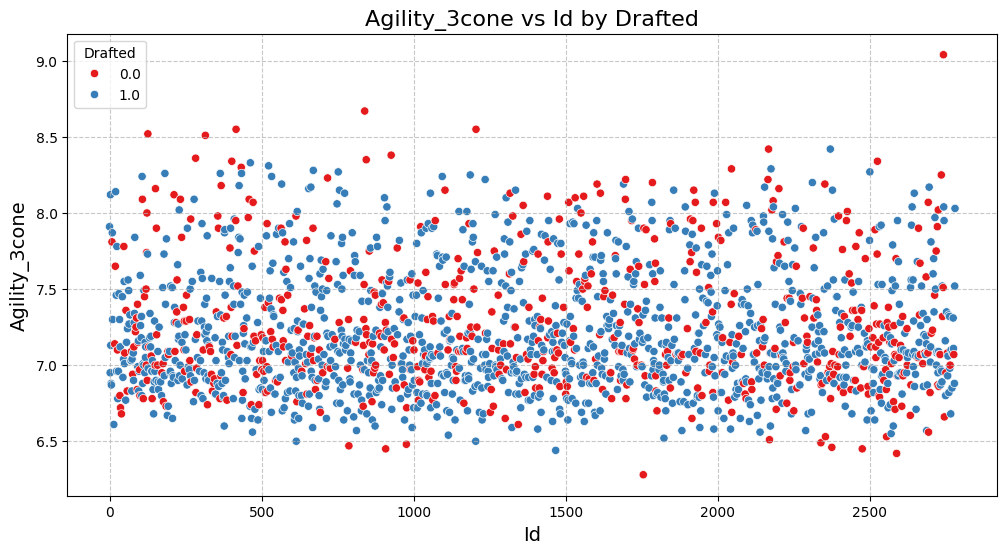

In [389]:
# 横軸にId、縦軸にAgility_3coneをプロット
# Dratedごとに色分け
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='Id', y='Agility_3cone', hue='Drafted', palette='Set1')
plt.title('Agility_3cone vs Id by Drafted', fontsize=16)
plt.xlabel('Id', fontsize=14)
plt.ylabel('Agility_3cone', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

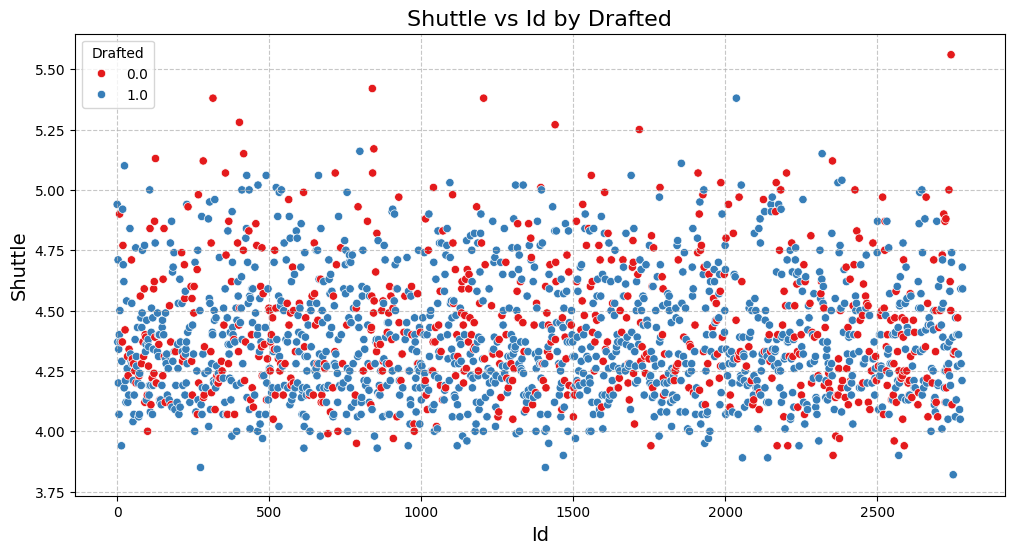

In [390]:
# 横軸にId、縦軸にShuttleをプロット
# Dratedごとに色分け
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='Id', y='Shuttle', hue='Drafted', palette='Set1')
plt.title('Shuttle vs Id by Drafted', fontsize=16)
plt.xlabel('Id', fontsize=14)
plt.ylabel('Shuttle', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

In [391]:
# カテゴリデータを抽出
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# 各列の水準数を取得
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


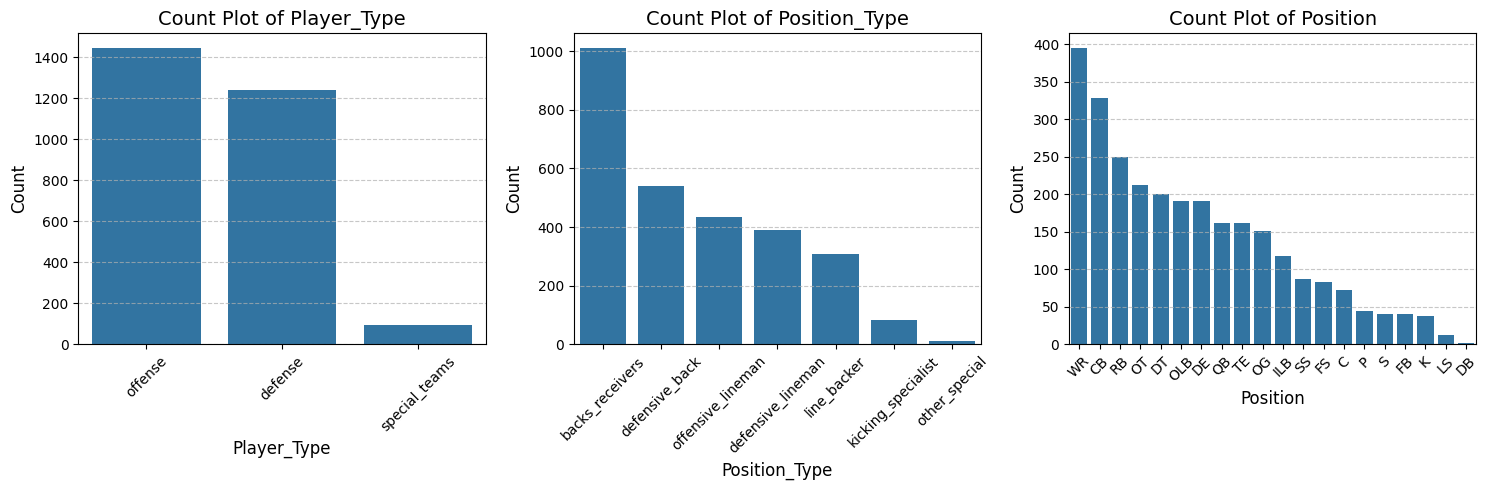

In [392]:
# カテゴリデータ（object型またはcategory型）を抽出し、School列を除外
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# グラフ描画準備
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 各カテゴリ変数でカウントプロット
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

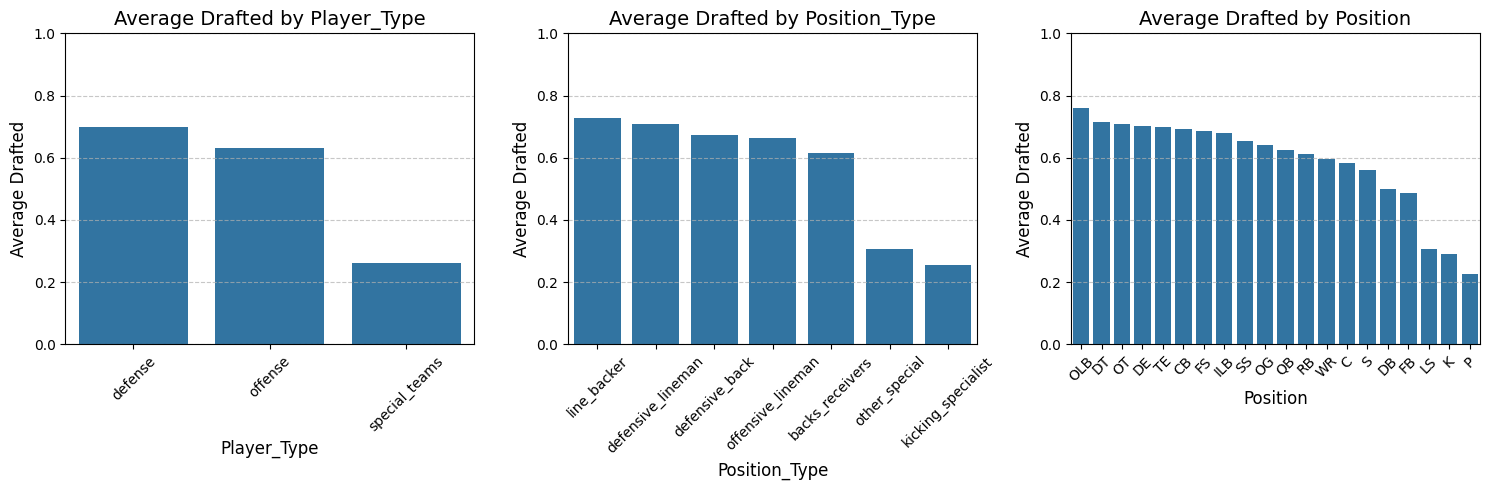

In [393]:
# カテゴリ変数（object型またはcategory型）を抽出し、School列を除外
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# グラフ描画準備
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 各カテゴリ変数ごとに Drafted 列の平均を棒グラフで描画
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [394]:
# 欠損値がある列を抽出
missing_cols = train.columns[train.isnull().any()]
# その人がdraftedされたかどうかの平均を表示
for col in missing_cols:
    # 欠損値がある列でDraftedされたかどうか数を出す
    mean_drafted = train.groupby(train[col].isnull())['Drafted'].mean()
    print(f"\nDrafted average for missing values in '{col}':")
    print(mean_drafted)


Drafted average for missing values in 'Age':
Age
False    0.765132
True     0.018391
Name: Drafted, dtype: float64

Drafted average for missing values in 'Sprint_40yd':
Sprint_40yd
False    0.651745
True     0.586207
Name: Drafted, dtype: float64

Drafted average for missing values in 'Vertical_Jump':
Vertical_Jump
False    0.664122
True     0.584838
Name: Drafted, dtype: float64

Drafted average for missing values in 'Bench_Press_Reps':
Bench_Press_Reps
False    0.664563
True     0.601942
Name: Drafted, dtype: float64

Drafted average for missing values in 'Broad_Jump':
Broad_Jump
False    0.662727
True     0.593804
Name: Drafted, dtype: float64

Drafted average for missing values in 'Agility_3cone':
Agility_3cone
False    0.671452
True     0.605155
Name: Drafted, dtype: float64

Drafted average for missing values in 'Shuttle':
Shuttle
False    0.671482
True     0.600877
Name: Drafted, dtype: float64


## Schoolの扱い

In [395]:
# schollごとのDraftedの平均を計算し、ターゲットエンコーディングを実施
# 母数が少ない大学はotherにまとめるなどの工夫も考えられるが、今回はシンプルに実装
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train['School_Target'] = 0.0
for train_idx, val_idx in skf.split(train, train['Drafted']):
    X_train, X_val = train.iloc[train_idx], train.iloc[val_idx]
    means = X_train.groupby('School')['Drafted'].mean()
    train.loc[val_idx, 'School_Target'] = X_val['School'].map(means)
# school-targetの欠損値は、全体の平均値で埋める
train['School_Target'] = train['School_Target'].fillna(train['Drafted'].mean())
# Test データにも School_Target を適用（Train 全体の学習統計を使用）
# 注意: 後続で test の 'School' を削除する前に作成しておく
global_school_means = train.groupby('School')['Drafted'].mean()
if 'School' in test.columns:
    test['School_Target'] = test['School'].map(global_school_means).fillna(train['Drafted'].mean())
else:
    # test に 'School' 列が既にない場合は全体平均で埋める（安全フォールバック）
    test['School_Target'] = train['Drafted'].mean()

## 4.　欠損値埋め

In [396]:
# 使わない列の削除
train = train.drop(columns=["Id", "School"])
test = test.drop(columns=["Id", "School"])

- ポジションごとの平均値で埋める

年齢は埋めない

In [397]:
# ポジションごとの平均値で欠損値を埋める
num_cols = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 
            'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in num_cols:
    # ポジションごとにグループ化して、その第一四分位数で埋める
    train[col] = train[col].fillna(train.groupby('Position')[col].transform('quantile', 0.25))
    test[col] = test[col].fillna(test.groupby('Position')[col].transform('quantile', 0.25))
    # それでも埋まらない場合（そのポジション全員が欠損している場合など）は全体の第一四分位数で埋める
    train[col] = train[col].fillna(train[col].quantile(0.25))
    test[col] = test[col].fillna(test[col].quantile(0.25))

In [398]:
# 年齢は-1で埋める
num_cols = ['Age']
for col in num_cols:
    train[col] = train[col].fillna(-1)
    test[col] = test[col].fillna(-1)

In [399]:
train.isnull().sum()

Year                0
Age                 0
Height              0
Weight              0
Sprint_40yd         0
Vertical_Jump       0
Bench_Press_Reps    0
Broad_Jump          0
Agility_3cone       0
Shuttle             0
Player_Type         0
Position_Type       0
Position            0
Drafted             0
School_Target       0
dtype: int64

In [400]:
test.isnull().sum()

Year                0
Age                 0
Height              0
Weight              0
Sprint_40yd         0
Vertical_Jump       0
Bench_Press_Reps    0
Broad_Jump          0
Agility_3cone       0
Shuttle             0
Player_Type         0
Position_Type       0
Position            0
School_Target       0
dtype: int64

In [401]:
# カテゴリデータをラベルエンコーディング
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

## 6. 仮説と特徴量エンジニアリング

In [402]:
# BMI 列の追加
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [403]:
# Speed_Score 列の追加
for df in [train, test]:
    df['Speed_Score'] = (df['Weight'] * 200) / (df['Sprint_40yd'] ** 4)

In [404]:
# 化け物(重いのに速い)列の追加
for df in [train,test]:
    df['BMI_Sprint'] = df['BMI'] / df['Sprint_40yd']

In [405]:
# Sprnt_40yd,Vertical_Jump,bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle をポジションごとの偏差値に変換
performance_cols = ['Sprint_40yd','Vertical_Jump','Bench_Press_Reps','Broad_Jump','Agility_3cone','Shuttle']
for col in performance_cols:
    for df in [train, test]:
        df[f'{col}_deviation'] = (df[col] - df.groupby('Position')[col].transform('mean'))/df.groupby('Year')[col].transform('std')

In [406]:
# Sprnt_40yd,Vertical_Jump,bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttleを消す
performance_cols = ['Sprint_40yd','Vertical_Jump','Bench_Press_Reps','Broad_Jump','Agility_3cone','Shuttle']
train = train.drop(columns=performance_cols)
test = test.drop(columns=performance_cols)


In [407]:
# column 一覧
for col in train.columns:
    print(col)

Year
Age
Height
Weight
Player_Type
Position_Type
Position
Drafted
School_Target
BMI
Speed_Score
BMI_Sprint
Sprint_40yd_deviation
Vertical_Jump_deviation
Bench_Press_Reps_deviation
Broad_Jump_deviation
Agility_3cone_deviation
Shuttle_deviation


# 7 モデル

In [408]:
# 特徴量と目的変数に分ける
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# スコア・予測格納用
auc_scores = []
test_pred_proba_list = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # バリデーション予測 & スコア
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

    # テストデータ予測を保存
    test_pred_proba = model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

# テスト予測の平均を計算
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

Fold 1
  AUC: 0.7983
Fold 2
  AUC: 0.7983
Fold 2
  AUC: 0.8498
Fold 3
  AUC: 0.8498
Fold 3
  AUC: 0.8699
Fold 4
  AUC: 0.8699
Fold 4
  AUC: 0.7916
Fold 5
  AUC: 0.7916
Fold 5
  AUC: 0.8261

Average Validation AUC: 0.8271
  AUC: 0.8261

Average Validation AUC: 0.8271


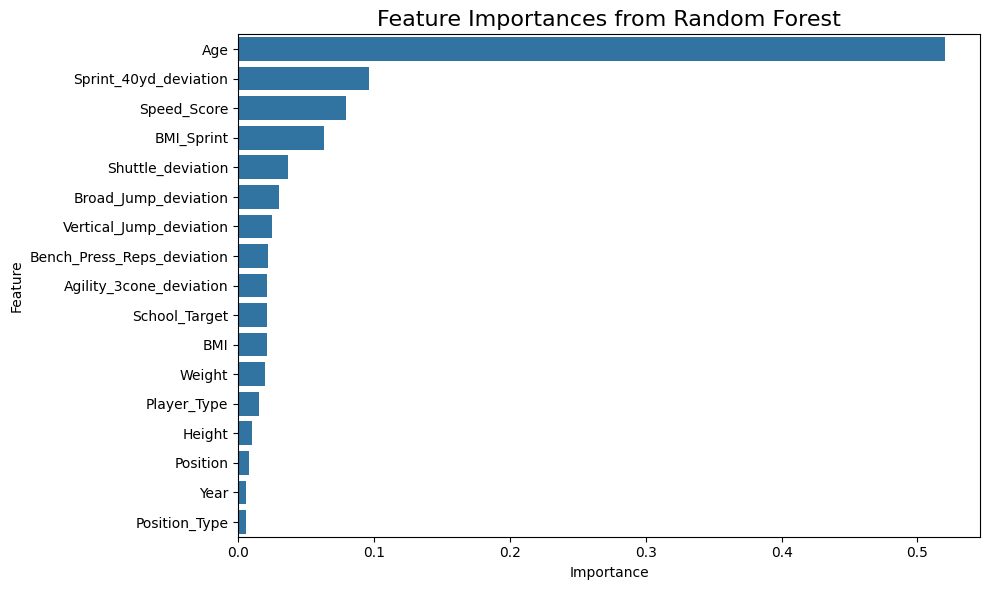

In [409]:
# 特徴量とその重要度をDataFrameにまとめる
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 可視化
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. 提出ファイル作成

In [410]:
# このセルを実行すると提出用のCSVファイルが作成されます
submission = pd.read_csv('data/sample_submission.csv') # PATHは必要に応じて変更の必要があります
submission["Drafted"] = test_pred_proba_mean
submission.to_csv('baseline_submission.csv', index=False)